# SRM Downscaling Data Access Utilities

This notebook demonstrates how to access, subset, and export SRM downscaling outputs for impact modeling. 

**Contents:**
1. Prerequisites and Setup
2. Loading and Exploring the Data Catalog
3. **Spatial Subsetting**: Point lookup, bounding box, country/region mask
4. Temporal Subsetting
5. Variable Selection and Transforms 
6. Export to NetCDF/CSV/Parquet

## 1. Prerequisites and Setup

Install dependencies if needed:
```bash
TODO
```

In [1]:
import geopandas as gpd
import intake
import xproj  # noqa - enables .proj accessor

## 2. Loading and Exploring the Data Catalog

We use `intake-esm` to access the CMIP6 downscaled data catalog. This allows us to search and filter datasets by various attributes.

In [2]:
cat = intake.open_esm_datastore(
    "https://rice1.osn.mghpcc.org/carbonplan/cp-cmip/version1/catalog/osn-rechunked-global-downscaled-cmip6.json"
)
cat = cat.search(timescale="month")
cat

,unique
activity_id,2
institution_id,7
source_id,6
experiment_id,4
member_id,1
timescale,1
variable_id,3
method,5
downscaled_daily_data_uri,113
version,1


In [3]:
cat.df

,activity_id,institution_id,source_id,experiment_id,member_id,timescale,variable_id,method,downscaled_daily_data_uri,version
0,CMIP,CCCma,CanESM5,historical,r1i1p1f1,month,pr,DeepSD-BC,https://rice1.osn.mghpcc.org/carbonplan/cp-cmi...,v1
1,CMIP,CCCma,CanESM5,historical,r1i1p1f1,month,tasmax,DeepSD-BC,https://rice1.osn.mghpcc.org/carbonplan/cp-cmi...,v1
2,CMIP,CCCma,CanESM5,historical,r1i1p1f1,month,tasmin,DeepSD-BC,https://rice1.osn.mghpcc.org/carbonplan/cp-cmi...,v1
3,CMIP,MRI,MRI-ESM2-0,historical,r1i1p1f1,month,pr,DeepSD-BC,https://rice1.osn.mghpcc.org/carbonplan/cp-cmi...,v1
4,CMIP,MRI,MRI-ESM2-0,historical,r1i1p1f1,month,tasmax,DeepSD-BC,https://rice1.osn.mghpcc.org/carbonplan/cp-cmi...,v1
...,...,...,...,...,...,...,...,...,...,...
108,ScenarioMIP,MRI,MRI-ESM2-0,ssp585,r1i1p1f1,month,pr,MACA,https://rice1.osn.mghpcc.org/carbonplan/cp-cmi...,v1
109,ScenarioMIP,MRI,MRI-ESM2-0,ssp585,r1i1p1f1,month,tasmax,MACA,https://rice1.osn.mghpcc.org/carbonplan/cp-cmi...,v1
110,ScenarioMIP,NCC,NorESM2-LM,ssp245,r1i1p1f1,month,pr,MACA,https://rice1.osn.mghpcc.org/carbonplan/cp-cmi...,v1
111,ScenarioMIP,NCC,NorESM2-LM,ssp245,r1i1p1f1,month,tasmax,MACA,https://rice1.osn.mghpcc.org/carbonplan/cp-cmi...,v1


In [4]:
cat_subset = cat.search(
    method="DeepSD-BC", variable_id=["pr", "tasmax"], experiment_id=["historical"]
)
cat_subset

,unique
activity_id,1
institution_id,2
source_id,2
experiment_id,1
member_id,1
timescale,1
variable_id,2
method,1
downscaled_daily_data_uri,4
version,1


In [5]:
cat_subset.df

,activity_id,institution_id,source_id,experiment_id,member_id,timescale,variable_id,method,downscaled_daily_data_uri,version
0,CMIP,CCCma,CanESM5,historical,r1i1p1f1,month,pr,DeepSD-BC,https://rice1.osn.mghpcc.org/carbonplan/cp-cmi...,v1
1,CMIP,CCCma,CanESM5,historical,r1i1p1f1,month,tasmax,DeepSD-BC,https://rice1.osn.mghpcc.org/carbonplan/cp-cmi...,v1
2,CMIP,MRI,MRI-ESM2-0,historical,r1i1p1f1,month,pr,DeepSD-BC,https://rice1.osn.mghpcc.org/carbonplan/cp-cmi...,v1
3,CMIP,MRI,MRI-ESM2-0,historical,r1i1p1f1,month,tasmax,DeepSD-BC,https://rice1.osn.mghpcc.org/carbonplan/cp-cmi...,v1


In [6]:
dsets = cat_subset.to_dataset_dict()
dsets


--> The keys in the returned dictionary of datasets are constructed as follows:
	'activity_id.institution_id.source_id.experiment_id.timescale.method'


{'CMIP.MRI.MRI-ESM2-0.historical.month.DeepSD-BC': <xarray.Dataset> Size: 6GB
 Dimensions:    (member_id: 1, time: 780, lat: 720, lon: 1440)
 Coordinates:
   * lat        (lat) float64 6kB -89.88 -89.62 -89.38 ... 89.38 89.62 89.88
   * lon        (lon) float64 12kB -179.9 -179.6 -179.4 ... 179.4 179.6 179.9
   * time       (time) datetime64[ns] 6kB 1950-01-01 1950-02-01 ... 2014-12-01
   * member_id  (member_id) object 8B 'r1i1p1f1'
 Data variables:
     pr         (member_id, time, lat, lon) float32 3GB dask.array<chunksize=(1, 780, 72, 144), meta=np.ndarray>
     tasmax     (member_id, time, lat, lon) float32 3GB dask.array<chunksize=(1, 780, 72, 144), meta=np.ndarray>
 Attributes: (12/26)
     Conventions:                      CF-1.8
     activity_id:                      CMIP
     cmip6_downscaling_contact:        hello@carbonplan.org
     cmip6_downscaling_explainer:      https://carbonplan.org/research/cmip6-d...
     cmip6_downscaling_institution:    CarbonPlan
     cmip6_downs

## 3. Spatial Subsetting

This section demonstrates three methods for spatial subsetting:
1. **Point lookup**: Extract a time series at a specific lat/lon location
2. **Bounding box**: Subset to a rectangular region
3. **Country/region mask**: Clip to a country or administrative boundary using shapefiles

In [7]:
# First, let's get one dataset to work with for spatial subsetting examples
# We'll select one dataset from the datatree
ds_key = list(dsets.keys())[0]
print(f"Working with dataset: {ds_key}")
ds = dsets[ds_key]
ds

Working with dataset: CMIP.MRI.MRI-ESM2-0.historical.month.DeepSD-BC


<xarray.Dataset> Size: 6GB
Dimensions:    (member_id: 1, time: 780, lat: 720, lon: 1440)
Coordinates:
  * lat        (lat) float64 6kB -89.88 -89.62 -89.38 ... 89.38 89.62 89.88
  * lon        (lon) float64 12kB -179.9 -179.6 -179.4 ... 179.4 179.6 179.9
  * time       (time) datetime64[ns] 6kB 1950-01-01 1950-02-01 ... 2014-12-01
  * member_id  (member_id) object 8B 'r1i1p1f1'
Data variables:
    pr         (member_id, time, lat, lon) float32 3GB dask.array<chunksize=(1, 780, 72, 144), meta=np.ndarray>
    tasmax     (member_id, time, lat, lon) float32 3GB dask.array<chunksize=(1, 780, 72, 144), meta=np.ndarray>
Attributes: (12/26)
    Conventions:                      CF-1.8
    activity_id:                      CMIP
    cmip6_downscaling_contact:        hello@carbonplan.org
    cmip6_downscaling_explainer:      https://carbonplan.org/research/cmip6-d...
    cmip6_downscaling_institution:    CarbonPlan
    cmip6_downscaling_license:        CC-BY-4.0
    ...                               ...
    intake_esm_attrs:member_id:       r1i1p1f1
    intake_esm_attrs:timescale:       month
    intake_esm_attrs:method:          DeepSD-BC
    intake_esm_attrs:version:         v1
    intake_esm_attrs:_data_format_:   zarr
    intake_esm_dataset_key:           CMIP.MRI.MRI-ESM2-0.historical.month.De...

### 3.1 Point Lookup

Extract a time series at a specific latitude/longitude location. This is useful for comparing model outputs to station observations or for site-specific impact studies.

In [8]:
# Define a point of interest (e.g., San Francisco, CA)
target_lat = 37.7749
target_lon = -122.4194

# Method 1: Nearest neighbor selection (fastest)
ds_point_nearest = ds.sel(lat=target_lat, lon=target_lon, method="nearest")
print(f"Point subset shape: {dict(ds_point_nearest.sizes)}")
ds_point_nearest

Point subset shape: {'member_id': 1, 'time': 780}


<xarray.Dataset> Size: 13kB
Dimensions:    (member_id: 1, time: 780)
Coordinates:
    lat        float64 8B 37.88
    lon        float64 8B -122.4
  * time       (time) datetime64[ns] 6kB 1950-01-01 1950-02-01 ... 2014-12-01
  * member_id  (member_id) object 8B 'r1i1p1f1'
Data variables:
    pr         (member_id, time) float32 3kB dask.array<chunksize=(1, 780), meta=np.ndarray>
    tasmax     (member_id, time) float32 3kB dask.array<chunksize=(1, 780), meta=np.ndarray>
Attributes: (12/26)
    Conventions:                      CF-1.8
    activity_id:                      CMIP
    cmip6_downscaling_contact:        hello@carbonplan.org
    cmip6_downscaling_explainer:      https://carbonplan.org/research/cmip6-d...
    cmip6_downscaling_institution:    CarbonPlan
    cmip6_downscaling_license:        CC-BY-4.0
    ...                               ...
    intake_esm_attrs:member_id:       r1i1p1f1
    intake_esm_attrs:timescale:       month
    intake_esm_attrs:method:          DeepSD-BC
    intake_esm_attrs:version:         v1
    intake_esm_attrs:_data_format_:   zarr
    intake_esm_dataset_key:           CMIP.MRI.MRI-ESM2-0.historical.month.De...

In [9]:
# Method 2: Interpolation to exact coordinates (more accurate but slower)
# ds_point_interp = ds.interp(lat=target_lat, lon=target_lon)
# print(f"Interpolated point shape: {dict(ds_point_interp.sizes)}")

# For multiple points, use a list of coordinates
locations = {
    "San Francisco": (37.7749, -122.4194),
    "Los Angeles": (34.0522, -118.2437),
    "Seattle": (47.6062, -122.3321),
}

# Extract nearest neighbor for each location
point_data = {}
for name, (lat, lon) in locations.items():
    point_data[name] = ds.sel(lat=lat, lon=lon, method="nearest")
    print(f"{name}: lat={point_data[name].lat.values:.2f}, lon={point_data[name].lon.values:.2f}")

San Francisco: lat=37.88, lon=-122.38
Los Angeles: lat=34.12, lon=-118.12
Seattle: lat=47.62, lon=-122.38


### 3.2 Bounding Box Subset

Extract a rectangular region defined by latitude/longitude bounds. Useful for regional studies.

In [10]:
# Define bounding box for California
bbox = {
    "lon_min": -124.5,
    "lon_max": -114.0,
    "lat_min": 32.5,
    "lat_max": 42.0,
}

# Subset using slice (works for regularly gridded data)
ds_bbox = ds.sel(
    lat=slice(bbox["lat_min"], bbox["lat_max"]), lon=slice(bbox["lon_min"], bbox["lon_max"])
)

print(f"Original shape: lat={ds.sizes.get('lat', 'N/A')}, lon={ds.sizes.get('lon', 'N/A')}")
print(f"Subset shape: lat={ds_bbox.sizes.get('lat', 'N/A')}, lon={ds_bbox.sizes.get('lon', 'N/A')}")
ds_bbox

Original shape: lat=720, lon=1440
Subset shape: lat=38, lon=42


<xarray.Dataset> Size: 10MB
Dimensions:    (member_id: 1, time: 780, lat: 38, lon: 42)
Coordinates:
  * lat        (lat) float64 304B 32.62 32.88 33.12 33.38 ... 41.38 41.62 41.88
  * lon        (lon) float64 336B -124.4 -124.1 -123.9 ... -114.6 -114.4 -114.1
  * time       (time) datetime64[ns] 6kB 1950-01-01 1950-02-01 ... 2014-12-01
  * member_id  (member_id) object 8B 'r1i1p1f1'
Data variables:
    pr         (member_id, time, lat, lon) float32 5MB dask.array<chunksize=(1, 780, 14, 42), meta=np.ndarray>
    tasmax     (member_id, time, lat, lon) float32 5MB dask.array<chunksize=(1, 780, 14, 42), meta=np.ndarray>
Attributes: (12/26)
    Conventions:                      CF-1.8
    activity_id:                      CMIP
    cmip6_downscaling_contact:        hello@carbonplan.org
    cmip6_downscaling_explainer:      https://carbonplan.org/research/cmip6-d...
    cmip6_downscaling_institution:    CarbonPlan
    cmip6_downscaling_license:        CC-BY-4.0
    ...                               ...
    intake_esm_attrs:member_id:       r1i1p1f1
    intake_esm_attrs:timescale:       month
    intake_esm_attrs:method:          DeepSD-BC
    intake_esm_attrs:version:         v1
    intake_esm_attrs:_data_format_:   zarr
    intake_esm_dataset_key:           CMIP.MRI.MRI-ESM2-0.historical.month.De...

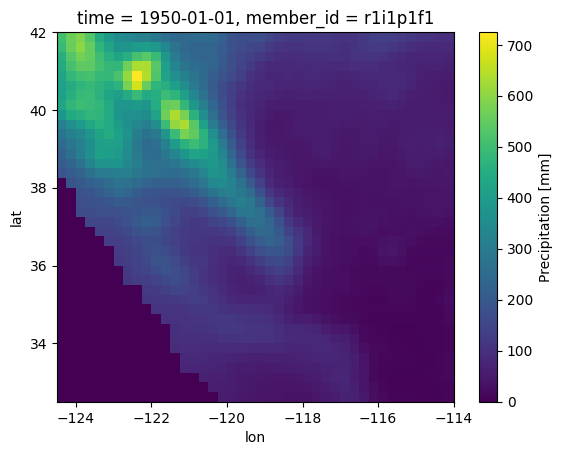

In [11]:
ds_bbox.pr.isel(time=0).squeeze().plot();

Western US subset: {'member_id': 1, 'time': 780, 'lat': 72, 'lon': 92}


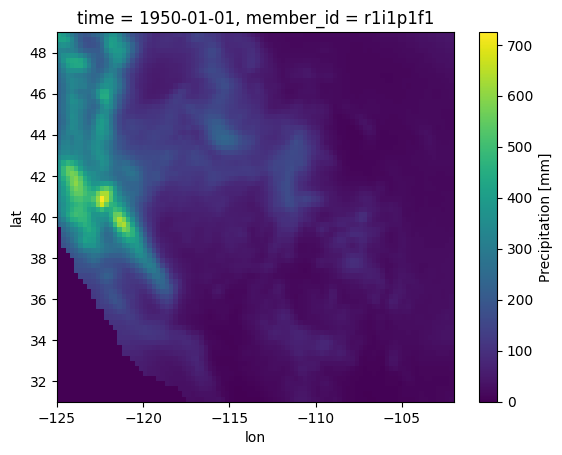

In [12]:
# Helper function for bounding box subsetting
def subset_bbox(ds, lon_min, lon_max, lat_min, lat_max):
    """
    Subset a dataset to a bounding box.

    Parameters
    ----------
    ds : xarray.Dataset
        Input dataset with lat/lon coordinates
    lon_min, lon_max : float
        Longitude bounds
    lat_min, lat_max : float
        Latitude bounds

    Returns
    -------
    xarray.Dataset
        Subsetted dataset
    """
    # Handle both ascending and descending latitude coordinates
    lat_slice = slice(lat_min, lat_max) if ds.lat[0] < ds.lat[-1] else slice(lat_max, lat_min)
    lon_slice = slice(lon_min, lon_max) if ds.lon[0] < ds.lon[-1] else slice(lon_max, lon_min)

    return ds.sel(lat=lat_slice, lon=lon_slice)


# Example: Western US region
ds_western_us = subset_bbox(ds, lon_min=-125, lon_max=-102, lat_min=31, lat_max=49)
print(f"Western US subset: {dict(ds_western_us.sizes)}")
ds_western_us.pr.squeeze().isel(time=0).plot();

### 3.3 Country/Region Mask

Clip data to country or administrative boundaries using `rasterix`. This package provides dask-aware wrappers for efficient geometry masking and clipping operations.

In [13]:
# Load Natural Earth country boundaries (with country names)
import pooch

countries_url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
countries_path = pooch.retrieve(countries_url, known_hash=None, processor=pooch.Unzip())
countries = gpd.read_file([p for p in countries_path if p.endswith(".shp")][0])
print(f"Available countries: {countries.shape[0]}")
countries[["NAME", "CONTINENT"]].head(10)

SHA256 hash of downloaded file: 0f243aeac8ac6cf26f0417285b0bd33ac47f1b5bdb719fd3e0df37d03ea37110
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.
Unzipping contents of '/opt/coiled/cache/pooch/dc4effaac49202a7c38534f86005997f-ne_110m_admin_0_countries.zip' to '/opt/coiled/cache/pooch/dc4effaac49202a7c38534f86005997f-ne_110m_admin_0_countries.zip.unzip'


Available countries: 177


,NAME,CONTINENT
0,Fiji,Oceania
1,Tanzania,Africa
2,W. Sahara,Africa
3,Canada,North America
4,United States of America,North America
5,Kazakhstan,Asia
6,Uzbekistan,Asia
7,Papua New Guinea,Oceania
8,Indonesia,Asia
9,Argentina,South America


In [14]:
# First, assign CRS to the dataset (required for rasterix operations)
ds_with_crs = ds.proj.assign_crs(spatial_ref="epsg:4326")
ds_with_crs

<xarray.Dataset> Size: 6GB
Dimensions:      (member_id: 1, time: 780, lat: 720, lon: 1440)
Coordinates:
  * lat          (lat) float64 6kB -89.88 -89.62 -89.38 ... 89.38 89.62 89.88
  * lon          (lon) float64 12kB -179.9 -179.6 -179.4 ... 179.4 179.6 179.9
  * time         (time) datetime64[ns] 6kB 1950-01-01 1950-02-01 ... 2014-12-01
  * member_id    (member_id) object 8B 'r1i1p1f1'
  * spatial_ref  int64 8B 0
Data variables:
    pr           (member_id, time, lat, lon) float32 3GB dask.array<chunksize=(1, 780, 72, 144), meta=np.ndarray>
    tasmax       (member_id, time, lat, lon) float32 3GB dask.array<chunksize=(1, 780, 72, 144), meta=np.ndarray>
Indexes:
    spatial_ref  CRSIndex (crs=EPSG:4326)
Attributes: (12/26)
    Conventions:                      CF-1.8
    activity_id:                      CMIP
    cmip6_downscaling_contact:        hello@carbonplan.org
    cmip6_downscaling_explainer:      https://carbonplan.org/research/cmip6-d...
    cmip6_downscaling_institution:    CarbonPlan
    cmip6_downscaling_license:        CC-BY-4.0
    ...                               ...
    intake_esm_attrs:member_id:       r1i1p1f1
    intake_esm_attrs:timescale:       month
    intake_esm_attrs:method:          DeepSD-BC
    intake_esm_attrs:version:         v1
    intake_esm_attrs:_data_format_:   zarr
    intake_esm_dataset_key:           CMIP.MRI.MRI-ESM2-0.historical.month.De...

Selected country: India
Bounds: [68.17664514  7.96553478 97.40256148 35.49400951]


<Axes: >

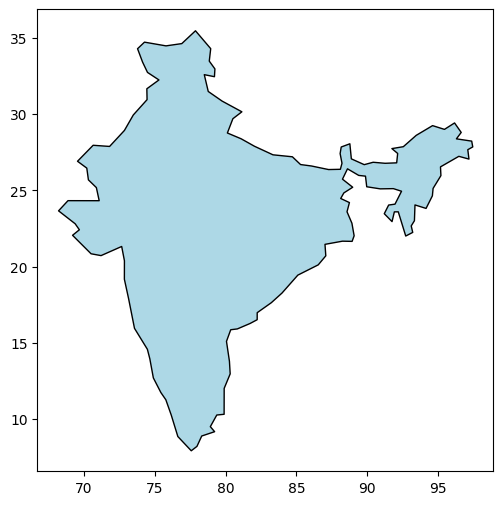

In [15]:
# Select a specific country (e.g., India)
country_name = "India"
country = countries[countries["NAME"] == country_name]
print(f"Selected country: {country_name}")
print(f"Bounds: {country.total_bounds}")  # [minx, miny, maxx, maxy]
country.plot(figsize=(8, 6), edgecolor="black", facecolor="lightblue")

#### Method 1: Geometry Mask

Create a boolean mask indicating which grid cells fall within the geometry. This is useful when you want to keep the original grid structure.

/opt/coiled/env/lib/python3.13/site-packages/rasterio/features.py:392: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  _rasterize(valid_shapes, out, transform, all_touched, merge_alg)


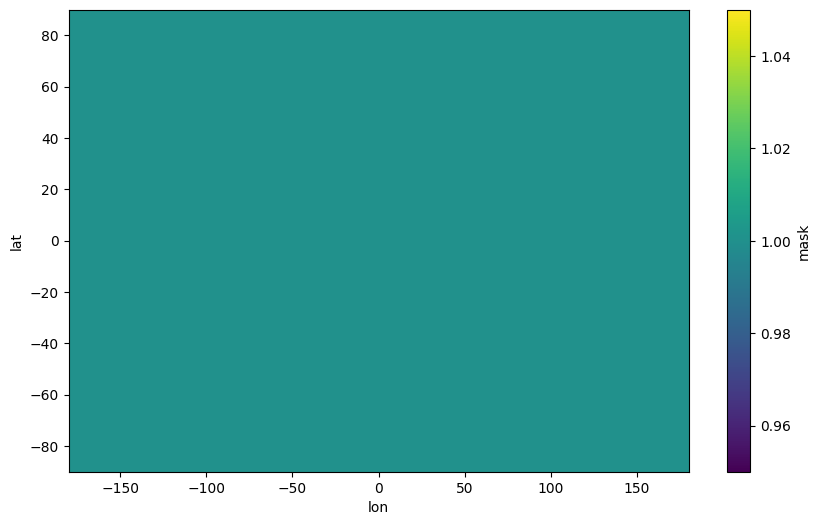

In [16]:
from rasterix.rasterize.rasterio import geometry_mask

# Create a mask from the country geometry
mask = geometry_mask(ds_with_crs, country[["geometry"]], xdim="lon", ydim="lat")

# Drop the spatial_ref coordinate for cleaner plotting
mask_clean = mask.drop_vars("spatial_ref", errors="ignore")
mask_clean.plot(figsize=(10, 6))

#### Method 2: Geometry Clip (Recommended)

Clip the dataset to the geometry bounds and mask values outside the geometry. This is more efficient as it reduces the data volume.

In [31]:
from rasterix.rasterize.rasterio import geometry_clip

# Clip the dataset to the country geometry
ds_clipped = geometry_clip(
    ds_with_crs, country[["geometry"]], xdim="lon", ydim="lat", clip=True
).drop_indexes("spatial_ref")
print(f"Clipped dataset shape: {dict(ds_clipped.sizes)}")
ds_clipped

Clipped dataset shape: {'member_id': 1, 'time': 780, 'lat': 110, 'lon': 117}


<xarray.Dataset> Size: 80MB
Dimensions:      (member_id: 1, time: 780, lat: 110, lon: 117)
Coordinates:
  * lat          (lat) float64 880B 8.125 8.375 8.625 ... 34.88 35.12 35.38
  * lon          (lon) float64 936B 68.38 68.62 68.88 ... 96.88 97.12 97.38
  * time         (time) datetime64[ns] 6kB 1950-01-01 1950-02-01 ... 2014-12-01
  * member_id    (member_id) object 8B 'r1i1p1f1'
    spatial_ref  int64 8B 0
Data variables:
    pr           (member_id, time, lat, lon) float32 40MB dask.array<chunksize=(1, 780, 40, 15), meta=np.ndarray>
    tasmax       (member_id, time, lat, lon) float32 40MB dask.array<chunksize=(1, 780, 40, 15), meta=np.ndarray>
Attributes: (12/26)
    Conventions:                      CF-1.8
    activity_id:                      CMIP
    cmip6_downscaling_contact:        hello@carbonplan.org
    cmip6_downscaling_explainer:      https://carbonplan.org/research/cmip6-d...
    cmip6_downscaling_institution:    CarbonPlan
    cmip6_downscaling_license:        CC-BY-4.0
    ...                               ...
    intake_esm_attrs:member_id:       r1i1p1f1
    intake_esm_attrs:timescale:       month
    intake_esm_attrs:method:          DeepSD-BC
    intake_esm_attrs:version:         v1
    intake_esm_attrs:_data_format_:   zarr
    intake_esm_dataset_key:           CMIP.MRI.MRI-ESM2-0.historical.month.De...

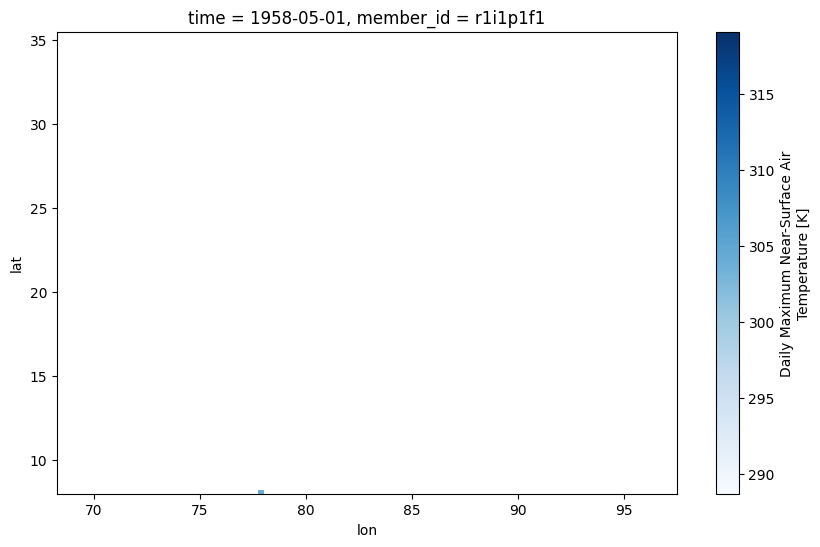

In [32]:
# Visualize the clipped precipitation data
ds_clipped["tasmax"].isel(time=100).squeeze().drop_vars("spatial_ref", errors="ignore").plot(
    figsize=(10, 6), robust=True, cmap="Blues"
)

#### Method 3: Out-of-Core Support with Dask

`rasterix` supports chunked/dask arrays for processing large datasets that don't fit in memory.

In [33]:
# Chunk the dataset for out-of-core processing
ds_chunked = ds_with_crs.chunk({"lat": -1, "lon": 120})

# geometry_clip works seamlessly with chunked data
ds_clipped_chunked = geometry_clip(ds_chunked, country[["geometry"]], xdim="lon", ydim="lat")
print("Chunked clipped dataset:")
ds_clipped_chunked

Chunked clipped dataset:


<xarray.Dataset> Size: 80MB
Dimensions:      (member_id: 1, time: 780, lat: 110, lon: 117)
Coordinates:
  * lat          (lat) float64 880B 8.125 8.375 8.625 ... 34.88 35.12 35.38
  * lon          (lon) float64 936B 68.38 68.62 68.88 ... 96.88 97.12 97.38
  * time         (time) datetime64[ns] 6kB 1950-01-01 1950-02-01 ... 2014-12-01
  * member_id    (member_id) object 8B 'r1i1p1f1'
  * spatial_ref  int64 8B 0
Data variables:
    pr           (member_id, time, lat, lon) float32 40MB dask.array<chunksize=(1, 780, 110, 87), meta=np.ndarray>
    tasmax       (member_id, time, lat, lon) float32 40MB dask.array<chunksize=(1, 780, 110, 87), meta=np.ndarray>
Indexes:
    spatial_ref  CRSIndex (crs=EPSG:4326)
Attributes: (12/26)
    Conventions:                      CF-1.8
    activity_id:                      CMIP
    cmip6_downscaling_contact:        hello@carbonplan.org
    cmip6_downscaling_explainer:      https://carbonplan.org/research/cmip6-d...
    cmip6_downscaling_institution:    CarbonPlan
    cmip6_downscaling_license:        CC-BY-4.0
    ...                               ...
    intake_esm_attrs:member_id:       r1i1p1f1
    intake_esm_attrs:timescale:       month
    intake_esm_attrs:method:          DeepSD-BC
    intake_esm_attrs:version:         v1
    intake_esm_attrs:_data_format_:   zarr
    intake_esm_dataset_key:           CMIP.MRI.MRI-ESM2-0.historical.month.De...

### 3.4 Spatial Subsetting Summary

| Method | Use Case | Performance | Package |
|--------|----------|-------------|---------|
| **Point (nearest)** | Single location time series | Fast | xarray |
| **Point (interp)** | Exact coordinates needed | Moderate | xarray |
| **Bounding box** | Rectangular regions | Fast | xarray |
| **geometry_mask** | Create boolean mask for geometries | Fast, Dask-aware | rasterix |
| **geometry_clip** | Clip to geometry bounds + mask | Fast, Dask-aware | rasterix |

**Tips:**
- Always assign CRS to your dataset before using rasterix: `ds.proj.assign_crs(spatial_ref="epsg:4326")`
- Use chunked datasets for large files that don't fit in memory
- `geometry_clip` is recommended for most use cases as it reduces data volume

## 4. Temporal Subsetting

This section demonstrates how to subset data by time, including:
- Selecting specific date ranges
- Selecting specific years, months, or seasons
- Resampling to different time frequencies

In [34]:
# Let's work with our clipped dataset for temporal examples
# First, check the time range of the data
print(f"Time range: {ds_clipped.time.values[0]} to {ds_clipped.time.values[-1]}")
print(f"Total time steps: {ds_clipped.sizes['time']}")

Time range: 1950-01-01T00:00:00.000000000 to 2014-12-01T00:00:00.000000000
Total time steps: 780


### 4.1 Date Range Selection

Select data within a specific date range using string-based indexing.

In [35]:
# Select a specific date range (e.g., 1990-2000)
ds_1990s = ds_clipped.sel(time=slice("1990-01-01", "1999-12-31"))
print(f"1990s subset: {ds_1990s.sizes['time']} time steps")
print(f"Date range: {ds_1990s.time.values[0]} to {ds_1990s.time.values[-1]}")
ds_1990s

1990s subset: 120 time steps
Date range: 1990-01-01T00:00:00.000000000 to 1999-12-01T00:00:00.000000000


<xarray.Dataset> Size: 12MB
Dimensions:      (member_id: 1, time: 120, lat: 110, lon: 117)
Coordinates:
  * lat          (lat) float64 880B 8.125 8.375 8.625 ... 34.88 35.12 35.38
  * lon          (lon) float64 936B 68.38 68.62 68.88 ... 96.88 97.12 97.38
  * time         (time) datetime64[ns] 960B 1990-01-01 1990-02-01 ... 1999-12-01
  * member_id    (member_id) object 8B 'r1i1p1f1'
    spatial_ref  int64 8B 0
Data variables:
    pr           (member_id, time, lat, lon) float32 6MB dask.array<chunksize=(1, 120, 40, 15), meta=np.ndarray>
    tasmax       (member_id, time, lat, lon) float32 6MB dask.array<chunksize=(1, 120, 40, 15), meta=np.ndarray>
Attributes: (12/26)
    Conventions:                      CF-1.8
    activity_id:                      CMIP
    cmip6_downscaling_contact:        hello@carbonplan.org
    cmip6_downscaling_explainer:      https://carbonplan.org/research/cmip6-d...
    cmip6_downscaling_institution:    CarbonPlan
    cmip6_downscaling_license:        CC-BY-4.0
    ...                               ...
    intake_esm_attrs:member_id:       r1i1p1f1
    intake_esm_attrs:timescale:       month
    intake_esm_attrs:method:          DeepSD-BC
    intake_esm_attrs:version:         v1
    intake_esm_attrs:_data_format_:   zarr
    intake_esm_dataset_key:           CMIP.MRI.MRI-ESM2-0.historical.month.De...

In [36]:
# Select a single year
ds_1995 = ds_clipped.sel(time="1995")
print(f"Year 1995: {ds_1995.sizes['time']} time steps")
ds_1995

Year 1995: 12 time steps


<xarray.Dataset> Size: 1MB
Dimensions:      (member_id: 1, time: 12, lat: 110, lon: 117)
Coordinates:
  * lat          (lat) float64 880B 8.125 8.375 8.625 ... 34.88 35.12 35.38
  * lon          (lon) float64 936B 68.38 68.62 68.88 ... 96.88 97.12 97.38
  * time         (time) datetime64[ns] 96B 1995-01-01 1995-02-01 ... 1995-12-01
  * member_id    (member_id) object 8B 'r1i1p1f1'
    spatial_ref  int64 8B 0
Data variables:
    pr           (member_id, time, lat, lon) float32 618kB dask.array<chunksize=(1, 12, 40, 15), meta=np.ndarray>
    tasmax       (member_id, time, lat, lon) float32 618kB dask.array<chunksize=(1, 12, 40, 15), meta=np.ndarray>
Attributes: (12/26)
    Conventions:                      CF-1.8
    activity_id:                      CMIP
    cmip6_downscaling_contact:        hello@carbonplan.org
    cmip6_downscaling_explainer:      https://carbonplan.org/research/cmip6-d...
    cmip6_downscaling_institution:    CarbonPlan
    cmip6_downscaling_license:        CC-BY-4.0
    ...                               ...
    intake_esm_attrs:member_id:       r1i1p1f1
    intake_esm_attrs:timescale:       month
    intake_esm_attrs:method:          DeepSD-BC
    intake_esm_attrs:version:         v1
    intake_esm_attrs:_data_format_:   zarr
    intake_esm_dataset_key:           CMIP.MRI.MRI-ESM2-0.historical.month.De...

### 4.2 Month and Season Selection

Filter data by specific months or meteorological seasons.

In [37]:
# Select specific months (e.g., summer months: June, July, August)
ds_summer = ds_clipped.sel(time=ds_clipped.time.dt.month.isin([6, 7, 8]))
print(f"Summer months (JJA): {ds_summer.sizes['time']} time steps")

# Select by season using xarray's season accessor
ds_winter = ds_clipped.sel(time=ds_clipped.time.dt.season == "DJF")
print(f"Winter season (DJF): {ds_winter.sizes['time']} time steps")

Summer months (JJA): 195 time steps
Winter season (DJF): 195 time steps


In [38]:
# Calculate seasonal climatology (mean across all years for each season)
ds_seasonal_clim = ds_clipped.groupby("time.season").mean("time")
print(f"Seasonal climatology dimensions: {dict(ds_seasonal_clim.sizes)}")
ds_seasonal_clim

Seasonal climatology dimensions: {'season': 4, 'member_id': 1, 'lat': 110, 'lon': 117}


<xarray.Dataset> Size: 414kB
Dimensions:      (season: 4, member_id: 1, lat: 110, lon: 117)
Coordinates:
  * lat          (lat) float64 880B 8.125 8.375 8.625 ... 34.88 35.12 35.38
  * lon          (lon) float64 936B 68.38 68.62 68.88 ... 96.88 97.12 97.38
  * member_id    (member_id) object 8B 'r1i1p1f1'
    spatial_ref  int64 8B 0
  * season       (season) object 32B 'DJF' 'JJA' 'MAM' 'SON'
Data variables:
    pr           (season, member_id, lat, lon) float32 206kB dask.array<chunksize=(4, 1, 40, 15), meta=np.ndarray>
    tasmax       (season, member_id, lat, lon) float32 206kB dask.array<chunksize=(4, 1, 40, 15), meta=np.ndarray>
Attributes: (12/26)
    Conventions:                      CF-1.8
    activity_id:                      CMIP
    cmip6_downscaling_contact:        hello@carbonplan.org
    cmip6_downscaling_explainer:      https://carbonplan.org/research/cmip6-d...
    cmip6_downscaling_institution:    CarbonPlan
    cmip6_downscaling_license:        CC-BY-4.0
    ...                               ...
    intake_esm_attrs:member_id:       r1i1p1f1
    intake_esm_attrs:timescale:       month
    intake_esm_attrs:method:          DeepSD-BC
    intake_esm_attrs:version:         v1
    intake_esm_attrs:_data_format_:   zarr
    intake_esm_dataset_key:           CMIP.MRI.MRI-ESM2-0.historical.month.De...

### 4.3 Temporal Resampling

Resample data to different time frequencies (e.g., monthly to annual).

In [39]:
# Resample monthly data to annual means
ds_annual = ds_clipped.resample(time="YE").mean()
print(f"Annual resampled: {ds_annual.sizes['time']} time steps")

# Resample to annual totals (useful for precipitation)
ds_annual_sum = ds_clipped["pr"].resample(time="YE").sum()
print(f"Annual precipitation totals: {ds_annual_sum.sizes['time']} time steps")

Annual resampled: 65 time steps
Annual precipitation totals: 65 time steps


In [40]:
# Helper function for temporal subsetting
def subset_time(ds, start_date=None, end_date=None, months=None, seasons=None):
    """
    Flexible temporal subsetting of a dataset.

    Parameters
    ----------
    ds : xarray.Dataset
        Input dataset with time coordinate
    start_date : str, optional
        Start date in 'YYYY-MM-DD' format
    end_date : str, optional
        End date in 'YYYY-MM-DD' format
    months : list of int, optional
        List of months to select (1-12)
    seasons : list of str, optional
        List of seasons to select ('DJF', 'MAM', 'JJA', 'SON')

    Returns
    -------
    xarray.Dataset
        Temporally subsetted dataset
    """
    result = ds

    # Date range selection
    if start_date or end_date:
        result = result.sel(time=slice(start_date, end_date))

    # Month selection
    if months:
        result = result.sel(time=result.time.dt.month.isin(months))

    # Season selection
    if seasons:
        result = result.sel(time=result.time.dt.season.isin(seasons))

    return result


# Example: Get summer months (JJA) for 1990-2000
ds_summer_90s = subset_time(
    ds_clipped, start_date="1990-01-01", end_date="1999-12-31", months=[6, 7, 8]
)
print(f"Summer 1990s: {ds_summer_90s.sizes['time']} time steps")

Summer 1990s: 30 time steps


### 4.4 Temporal Subsetting Summary

| Method | Use Case | Example |
|--------|----------|---------|
| **Date range** | Specific time period | `ds.sel(time=slice("1990", "2000"))` |
| **Single year** | One year of data | `ds.sel(time="1995")` |
| **Month filter** | Specific months | `ds.sel(time=ds.time.dt.month.isin([6,7,8]))` |
| **Season filter** | Meteorological seasons | `ds.sel(time=ds.time.dt.season=="DJF")` |
| **Resample** | Change time frequency | `ds.resample(time="YE").mean()` |
| **Groupby** | Climatologies | `ds.groupby("time.season").mean()` |

## 5. Variable Selection and Transforms

This section covers:
- Selecting specific variables from a dataset
- Unit conversions (e.g., Kelvin to Celsius)
- Computing derived variables (e.g., temperature range)
- Applying custom transformations

### 5.1 Variable Selection

Select specific variables from a multi-variable dataset.

In [41]:
# View available variables in the dataset
print("Available variables:")
for var in ds_clipped.data_vars:
    print(f"  - {var}: {ds_clipped[var].attrs.get('long_name', 'No description')}")

Available variables:
  - pr: Precipitation
  - tasmax: Daily Maximum Near-Surface Air Temperature


In [42]:
# Select a single variable (returns a DataArray)
tasmax = ds_clipped["tasmax"]
print(f"Single variable type: {type(tasmax).__name__}")
print(f"Shape: {dict(tasmax.sizes)}")

# Select multiple variables (returns a Dataset)
ds_temp_vars = ds_clipped[["tasmax", "pr"]]
print(f"\nMultiple variables type: {type(ds_temp_vars).__name__}")
print(f"Variables: {list(ds_temp_vars.data_vars)}")

Single variable type: DataArray
Shape: {'member_id': 1, 'time': 780, 'lat': 110, 'lon': 117}

Multiple variables type: Dataset
Variables: ['tasmax', 'pr']


### 5.2 Unit Conversions

Common unit conversions for climate data.

In [43]:
# Check current units
print(f"tasmax units: {ds_clipped['tasmax'].attrs.get('units', 'unknown')}")
print(f"pr units: {ds_clipped['pr'].attrs.get('units', 'unknown')}")

tasmax units: K
pr units: mm


In [44]:
# Temperature: Kelvin to Celsius
def kelvin_to_celsius(da):
    """Convert temperature from Kelvin to Celsius."""
    da_celsius = da - 273.15
    da_celsius.attrs = da.attrs.copy()
    da_celsius.attrs["units"] = "°C"
    return da_celsius


# Apply conversion
tasmax_celsius = kelvin_to_celsius(ds_clipped["tasmax"])
print(f"Original mean: {float(ds_clipped['tasmax'].mean()):.2f} K")
print(f"Converted mean: {float(tasmax_celsius.mean()):.2f} °C")

Original mean: 301.68 K
Converted mean: 28.53 °C


In [45]:
# Precipitation: kg m-2 s-1 to mm/day
def precip_to_mm_day(da):
    """Convert precipitation from kg m-2 s-1 to mm/day."""
    # 1 kg/m2/s = 86400 mm/day (since 1 kg/m2 = 1 mm for water)
    da_mm = da * 86400
    da_mm.attrs = da.attrs.copy()
    da_mm.attrs["units"] = "mm/day"
    return da_mm


# Apply conversion
pr_mm = precip_to_mm_day(ds_clipped["pr"])
print(f"Original mean: {float(ds_clipped['pr'].mean()):.2e} kg m-2 s-1")
print(f"Converted mean: {float(pr_mm.mean()):.2f} mm/day")

Original mean: 7.12e+01 kg m-2 s-1
Converted mean: 6149526.50 mm/day


### 5.3 Computing Derived Variables

Calculate new variables from existing ones.

In [46]:
# Create a dataset with converted units
ds_converted = ds_clipped.copy()

# Add converted variables
ds_converted["tasmax_celsius"] = kelvin_to_celsius(ds_converted["tasmax"])
ds_converted["pr_mm_day"] = precip_to_mm_day(ds_converted["pr"])

print("Dataset with converted variables:")
print(f"Variables: {list(ds_converted.data_vars)}")
ds_converted

Dataset with converted variables:
Variables: ['pr', 'tasmax', 'tasmax_celsius', 'pr_mm_day']


<xarray.Dataset> Size: 161MB
Dimensions:         (member_id: 1, time: 780, lat: 110, lon: 117)
Coordinates:
  * lat             (lat) float64 880B 8.125 8.375 8.625 ... 34.88 35.12 35.38
  * lon             (lon) float64 936B 68.38 68.62 68.88 ... 96.88 97.12 97.38
  * time            (time) datetime64[ns] 6kB 1950-01-01 ... 2014-12-01
  * member_id       (member_id) object 8B 'r1i1p1f1'
    spatial_ref     int64 8B 0
Data variables:
    pr              (member_id, time, lat, lon) float32 40MB dask.array<chunksize=(1, 780, 40, 15), meta=np.ndarray>
    tasmax          (member_id, time, lat, lon) float32 40MB dask.array<chunksize=(1, 780, 40, 15), meta=np.ndarray>
    tasmax_celsius  (member_id, time, lat, lon) float32 40MB dask.array<chunksize=(1, 780, 40, 15), meta=np.ndarray>
    pr_mm_day       (member_id, time, lat, lon) float32 40MB dask.array<chunksize=(1, 780, 40, 15), meta=np.ndarray>
Attributes: (12/26)
    Conventions:                      CF-1.8
    activity_id:                      CMIP
    cmip6_downscaling_contact:        hello@carbonplan.org
    cmip6_downscaling_explainer:      https://carbonplan.org/research/cmip6-d...
    cmip6_downscaling_institution:    CarbonPlan
    cmip6_downscaling_license:        CC-BY-4.0
    ...                               ...
    intake_esm_attrs:member_id:       r1i1p1f1
    intake_esm_attrs:timescale:       month
    intake_esm_attrs:method:          DeepSD-BC
    intake_esm_attrs:version:         v1
    intake_esm_attrs:_data_format_:   zarr
    intake_esm_dataset_key:           CMIP.MRI.MRI-ESM2-0.historical.month.De...

In [47]:
# Compute anomalies relative to a baseline period
baseline_start = "1980-01-01"
baseline_end = "2000-12-31"

# Calculate baseline climatology (monthly means)
baseline = ds_clipped.sel(time=slice(baseline_start, baseline_end))
baseline_clim = baseline.groupby("time.month").mean("time")

# Calculate anomalies
anomalies = ds_clipped.groupby("time.month") - baseline_clim
print(f"Anomalies computed relative to {baseline_start} to {baseline_end}")
anomalies

Anomalies computed relative to 1980-01-01 to 2000-12-31


<xarray.Dataset> Size: 80MB
Dimensions:      (lat: 110, lon: 117, time: 780, member_id: 1)
Coordinates:
  * lat          (lat) float64 880B 8.125 8.375 8.625 ... 34.88 35.12 35.38
  * lon          (lon) float64 936B 68.38 68.62 68.88 ... 96.88 97.12 97.38
  * time         (time) datetime64[ns] 6kB 1950-01-01 1950-02-01 ... 2014-12-01
  * member_id    (member_id) object 8B 'r1i1p1f1'
    spatial_ref  (time) int64 6kB 0 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0 0
    month        (time) int64 6kB 1 2 3 4 5 6 7 8 9 10 ... 4 5 6 7 8 9 10 11 12
Data variables:
    pr           (member_id, time, lat, lon) float32 40MB dask.array<chunksize=(1, 12, 40, 15), meta=np.ndarray>
    tasmax       (member_id, time, lat, lon) float32 40MB dask.array<chunksize=(1, 12, 40, 15), meta=np.ndarray>

### 5.4 Applying Custom Transformations

Apply custom functions across the dataset using xarray's `apply_ufunc` or simple arithmetic.

In [48]:
import numpy as np

# Calculate running mean (e.g., 12-month rolling average)
tasmax_rolling = ds_clipped["tasmax"].rolling(time=12, center=True).mean()
print(f"Rolling mean shape: {dict(tasmax_rolling.sizes)}")

# Calculate percentiles
tasmax_p95 = ds_clipped["tasmax"].quantile(0.95, dim="time")
print(f"95th percentile shape: {dict(tasmax_p95.sizes)}")

Rolling mean shape: {'member_id': 1, 'time': 780, 'lat': 110, 'lon': 117}
95th percentile shape: {'member_id': 1, 'lat': 110, 'lon': 117}


In [49]:
# Standardize data (z-scores)
def standardize(da, dim="time"):
    """Standardize data to z-scores along a dimension."""
    mean = da.mean(dim=dim)
    std = da.std(dim=dim)
    return (da - mean) / std


tasmax_zscore = standardize(ds_clipped["tasmax"])
print(f"Z-score mean: {float(tasmax_zscore.mean()):.6f} (should be ~0)")
print(f"Z-score std: {float(tasmax_zscore.std()):.6f} (should be ~1)")

Z-score mean: 0.000062 (should be ~0)
Z-score std: 1.000000 (should be ~1)


## 6. Export to NetCDF/CSV/Parquet

This section demonstrates how to export processed data to different formats:
- **NetCDF**: Standard format for gridded climate data
- **CSV**: Tabular format for point data or simple analysis
- **Parquet**: Efficient columnar format for large tabular datasets

In [50]:
# Create output directory
from pathlib import Path

output_dir = Path("/tmp/exports")
output_dir.mkdir(exist_ok=True)
print(f"Output directory: {output_dir.absolute()}")

Output directory: /tmp/exports


### 6.1 Export to NetCDF

NetCDF is the standard format for gridded climate data, preserving coordinates, attributes, and metadata.

In [51]:
# Prepare a subset for export (smaller dataset for demo)
ds_export = ds_clipped.sel(time=slice("1990-01-01", "1995-12-31"))
print(f"Export dataset shape: {dict(ds_export.sizes)}")

# Basic NetCDF export
netcdf_path = output_dir / "india_climate_1990-1995.nc"
ds_export.to_netcdf(netcdf_path)
print(f"Saved to: {netcdf_path}")
print(f"File size: {netcdf_path.stat().st_size / 1024:.1f} KB")

Export dataset shape: {'member_id': 1, 'time': 72, 'lat': 110, 'lon': 117}
Saved to: /tmp/exports/india_climate_1990-1995.nc
File size: 7260.3 KB


In [52]:
# Export with compression (recommended for large files)
encoding = {var: {"zlib": True, "complevel": 5} for var in ds_export.data_vars}

netcdf_compressed_path = output_dir / "india_climate_1990-1995_compressed.nc"
ds_export.to_netcdf(netcdf_compressed_path, encoding=encoding)
print(f"Compressed file size: {netcdf_compressed_path.stat().st_size / 1024:.1f} KB")

Compressed file size: 71.8 KB


### 6.2 Export to CSV

CSV format is useful for point data or when sharing with non-Python tools. Best suited for 1D or 2D data.

In [53]:
# Export point data to CSV
# First, extract a single point time series
point_lat, point_lon = 28.6, 77.2  # Delhi, India
point_data = ds_export.sel(lat=point_lat, lon=point_lon, method="nearest")

# Convert to pandas DataFrame
df_point = point_data.to_dataframe().reset_index()
print(f"Point data shape: {df_point.shape}")
df_point.head()

Point data shape: (72, 7)


,member_id,time,pr,tasmax,lat,lon,spatial_ref
0,r1i1p1f1,1990-01-01,NaN,NaN,28.625,77.125,0
1,r1i1p1f1,1990-02-01,NaN,NaN,28.625,77.125,0
2,r1i1p1f1,1990-03-01,NaN,NaN,28.625,77.125,0
3,r1i1p1f1,1990-04-01,NaN,NaN,28.625,77.125,0
4,r1i1p1f1,1990-05-01,NaN,NaN,28.625,77.125,0


In [54]:
# Save to CSV
csv_path = output_dir / "delhi_climate_1990-1995.csv"
df_point.to_csv(csv_path, index=False)
print(f"Saved to: {csv_path}")
print(f"File size: {csv_path.stat().st_size / 1024:.1f} KB")

Saved to: /tmp/exports/delhi_climate_1990-1995.csv
File size: 2.7 KB


In [55]:
# Export spatial average time series to CSV
# Calculate area-weighted mean over the region
weights = np.cos(np.deg2rad(ds_export.lat))
ds_weighted_mean = ds_export.weighted(weights).mean(dim=["lat", "lon"])

df_regional = ds_weighted_mean.to_dataframe().reset_index()
csv_regional_path = output_dir / "india_regional_mean_1990-1995.csv"
df_regional.to_csv(csv_regional_path, index=False)
print(f"Regional mean saved to: {csv_regional_path}")
df_regional.head()

Regional mean saved to: /tmp/exports/india_regional_mean_1990-1995.csv


,time,member_id,spatial_ref,pr,tasmax
0,1990-01-01,r1i1p1f1,0,11.947864,301.705444
1,1990-02-01,r1i1p1f1,0,11.551138,301.760590
2,1990-03-01,r1i1p1f1,0,12.191964,302.389374
3,1990-04-01,r1i1p1f1,0,29.719397,303.072571
4,1990-05-01,r1i1p1f1,0,19.418512,303.050110


### 6.3 Export to Parquet

Parquet is an efficient columnar format ideal for large tabular datasets. It's faster to read/write than CSV and supports compression.

In [56]:
# Convert gridded data to a flat DataFrame (useful for tabular analysis)
# Note: This can create very large DataFrames for high-resolution data!
ds_small = ds_export.sel(time=slice("1990-01-01", "1990-12-31"))  # Just 1 year for demo
df_grid = ds_small.to_dataframe().reset_index()
print(f"Flattened grid shape: {df_grid.shape}")
df_grid.head()

Flattened grid shape: (154440, 7)


,member_id,time,lat,lon,pr,tasmax,spatial_ref
0,r1i1p1f1,1990-01-01,8.125,68.375,NaN,NaN,0
1,r1i1p1f1,1990-01-01,8.125,68.625,NaN,NaN,0
2,r1i1p1f1,1990-01-01,8.125,68.875,NaN,NaN,0
3,r1i1p1f1,1990-01-01,8.125,69.125,NaN,NaN,0
4,r1i1p1f1,1990-01-01,8.125,69.375,NaN,NaN,0


In [57]:
# Export to Parquet
parquet_path = output_dir / "india_climate_1990.parquet"
df_grid.to_parquet(parquet_path, index=False, compression="snappy")
print(f"Saved to: {parquet_path}")
print(f"File size: {parquet_path.stat().st_size / 1024:.1f} KB")

Saved to: /tmp/exports/india_climate_1990.parquet
File size: 14.8 KB


In [58]:
# Compare file sizes

# Export same data to CSV for comparison
csv_comparison_path = output_dir / "india_climate_1990.csv"
df_grid.to_csv(csv_comparison_path, index=False)

print("File size comparison:")
print(f"  CSV:     {csv_comparison_path.stat().st_size / 1024:.1f} KB")
print(f"  Parquet: {parquet_path.stat().st_size / 1024:.1f} KB")
print(
    f"  Parquet is {csv_comparison_path.stat().st_size / parquet_path.stat().st_size:.1f}x smaller"
)

File size comparison:
  CSV:     5720.5 KB
  Parquet: 14.8 KB
  Parquet is 387.1x smaller


### 6.4 Export Format Summary

| Format | Best For | Pros | Cons |
|--------|----------|------|------|
| **NetCDF** | Gridded climate data | Preserves coordinates, metadata, CF-compliant | Requires specialized tools to read |
| **CSV** | Point data, simple sharing | Universal compatibility | Large files, slow I/O, no compression |
| **Parquet** | Large tabular datasets | Fast I/O, compressed, columnar | Requires pyarrow/fastparquet |

**Tips:**
- Use NetCDF for gridded data that needs to preserve spatial structure
- Use CSV for small datasets or when sharing with Excel/non-Python users
- Use Parquet for large tabular datasets or data pipelines

In [59]:
# Clean up: List all exported files
print("Exported files:")
for f in sorted(output_dir.glob("*")):
    print(f"  {f.name}: {f.stat().st_size / 1024:.1f} KB")

Exported files:
  delhi_climate_1990-1995.csv: 2.7 KB
  india_climate_1990-1995.nc: 7260.3 KB
  india_climate_1990-1995_compressed.nc: 71.8 KB
  india_climate_1990.csv: 5720.5 KB
  india_climate_1990.parquet: 14.8 KB
  india_regional_mean_1990-1995.csv: 4.2 KB
